# Quickstart

This notebook walks through the two main ways to use **linum-basic**:

1. **One-liner** — `correct_images(stack)` for quick batch correction.
2. **Step-by-step** — `BaSiC` class for inspection, reuse, and fine control.

No external data is needed: a synthetic shaded stack is generated from the
bundled sample image using pure NumPy.

## Setup

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

import linum_basic
from linum_basic import BaSiC, correct_images
from linum_basic.data import load_sample_image

plt.rcParams.update(
    {
        "figure.dpi": 150,
        "savefig.dpi": 150,
        "figure.facecolor": "white",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
print(f"linum-basic version: {linum_basic.__version__}")

linum-basic version: 0.2.0


## 1. Build a synthetic shaded stack

We tile the bundled greyscale sample image into 64 × 64 patches, then apply
a Gaussian vignette (flat-field) and a constant dark-field offset — the same
physical model BaSiC is designed to invert.

In [2]:
TILE = 64
rng = np.random.default_rng(42)

# --- Ground-truth shading fields -------------------------------------------
y, x = np.mgrid[-1 : 1 : TILE * 1j, -1 : 1 : TILE * 1j]  # type: ignore[misc]
gt_flat = (0.6 + 0.4 * np.exp(-2.0 * (x**2 + y**2))).astype(np.float32)
gt_flat /= gt_flat.mean()  # normalise to mean = 1
gt_dark = (0.03 * np.ones((TILE, TILE))).astype(np.float32)

# --- Tile the sample image --------------------------------------------------
source = load_sample_image().astype(np.float32) / 255.0
h, w = source.shape
nh, nw = h // TILE, w // TILE
tiles = [source[r * TILE : (r + 1) * TILE, c * TILE : (c + 1) * TILE] for r in range(nh) for c in range(nw)]

# --- Apply shading ----------------------------------------------------------
brightness = rng.uniform(0.3, 0.9, (len(tiles), 1, 1)).astype(np.float32)
clean = np.stack(tiles).astype(np.float32)
shaded = clean * brightness * gt_flat + gt_dark

print(f"Stack shape : {shaded.shape}  ({len(tiles)} patches)")
print(f"Flat-field  : mean={gt_flat.mean():.3f}  min={gt_flat.min():.3f}  max={gt_flat.max():.3f}")
print(f"Dark-field  : mean={gt_dark.mean():.3f}")

Stack shape : (704, 64, 64)  (704 patches)
Flat-field  : mean=1.000  min=0.821  max=1.351
Dark-field  : mean=0.030


### Visualise the raw stack

The vignette is clearly visible: patches are brighter at the centre and
progressively dimmer towards the edges.

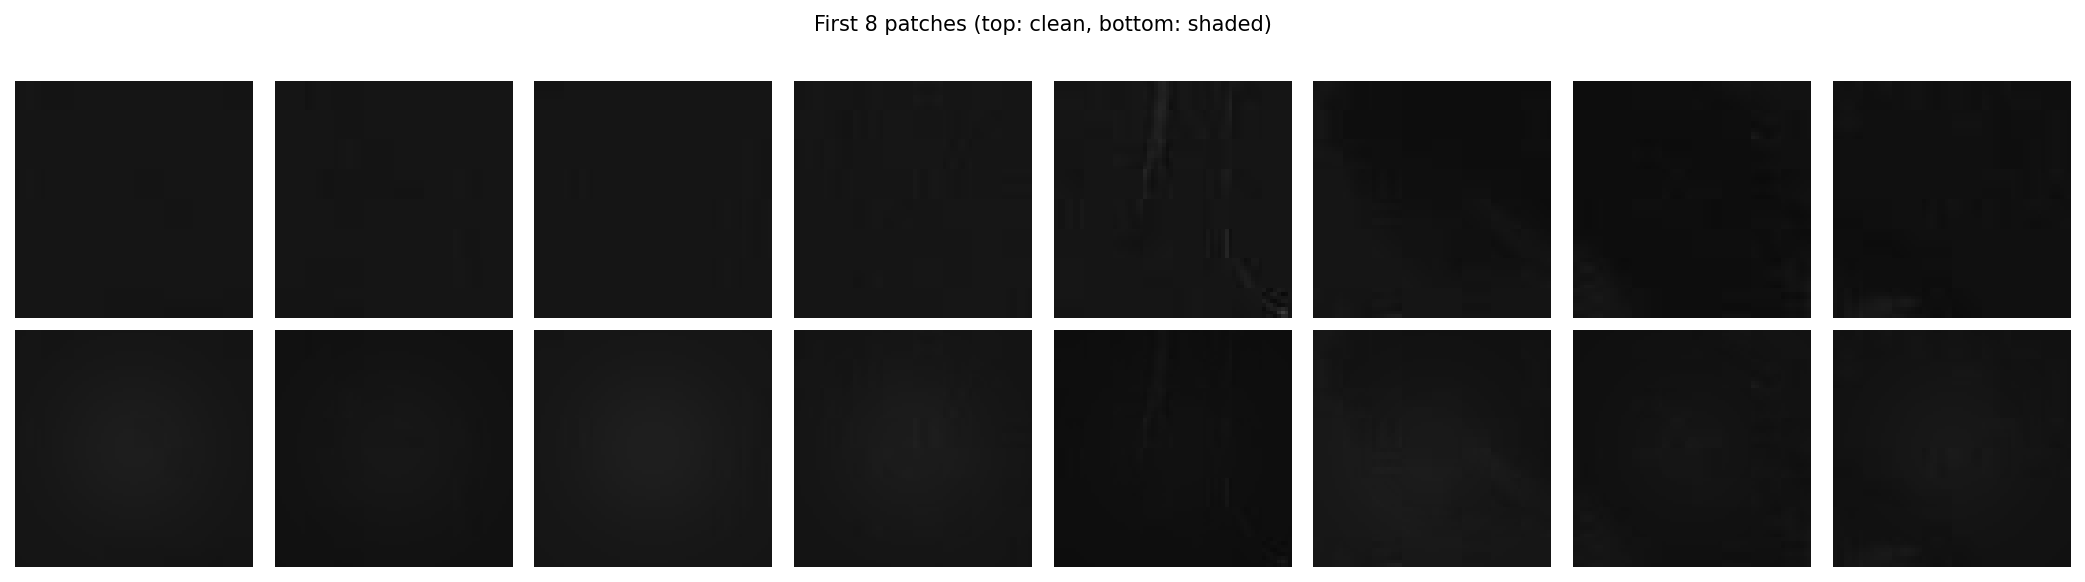

In [3]:
n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(14, 4))
for i in range(n_show):
    axes[0, i].imshow(clean[i], cmap="gray", vmin=0, vmax=1)
    axes[0, i].axis("off")
    axes[1, i].imshow(shaded[i], cmap="gray", vmin=0, vmax=1)
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Clean", fontsize=9)
axes[1, 0].set_ylabel("Shaded", fontsize=9)
fig.suptitle("First 8 patches (top: clean, bottom: shaded)", fontsize=10)
plt.tight_layout()
plt.show()

## 2. One-liner correction — `correct_images()`

`correct_images()` is the simplest entry point: pass a stack, get a corrected
stack back.  Internally it constructs a `BaSiC` instance, runs the full
optimisation, and applies the estimated correction in one call.

In [4]:
corrected_oneliner = correct_images(
    shaded,
    estimate_darkfield=True,  # jointly estimate dark-field
    working_size=64,  # internal optimisation resolution
)

print(f"Input  : {shaded.shape}  dtype={shaded.dtype}")
print(f"Output : {corrected_oneliner.shape}  dtype={corrected_oneliner.dtype}")

Input  : (704, 64, 64)  dtype=float32
Output : (704, 64, 64)  dtype=float32


## 3. Step-by-step — `BaSiC` class

Use the `BaSiC` class when you need to:

- Inspect the estimated flat-field / dark-field.
- Apply the same correction to new images (`normalize()`).
- Override regularisation weights (`l_s`, `l_d`).
- Write corrected images back to disk (`write_images()`).

In [5]:
model = BaSiC(shaded, estimate_darkfield=True)

# prepare() loads data and auto-tunes the regularisation weights
model.prepare()
print(f"Auto-tuned  l_s = {model.l_s:.4f}")
print(f"Auto-tuned  l_d = {model.l_d:.4f}")

# run() executes the reweighted ALM loop and returns self for chaining
model.run()

# Retrieve the estimated fields
flatfield = model.get_flatfield()
darkfield = model.get_darkfield()
print(f"\nFlat-field  shape={flatfield.shape}  mean={flatfield.mean():.4f}")
print(f"Dark-field  shape={darkfield.shape}  mean={darkfield.mean():.6f}")

Auto-tuned  l_s = 0.2571
Auto-tuned  l_d = 0.1028

Flat-field  shape=(64, 64)  mean=1.0000
Dark-field  shape=(64, 64)  mean=0.030000


### Inspect the estimated fields

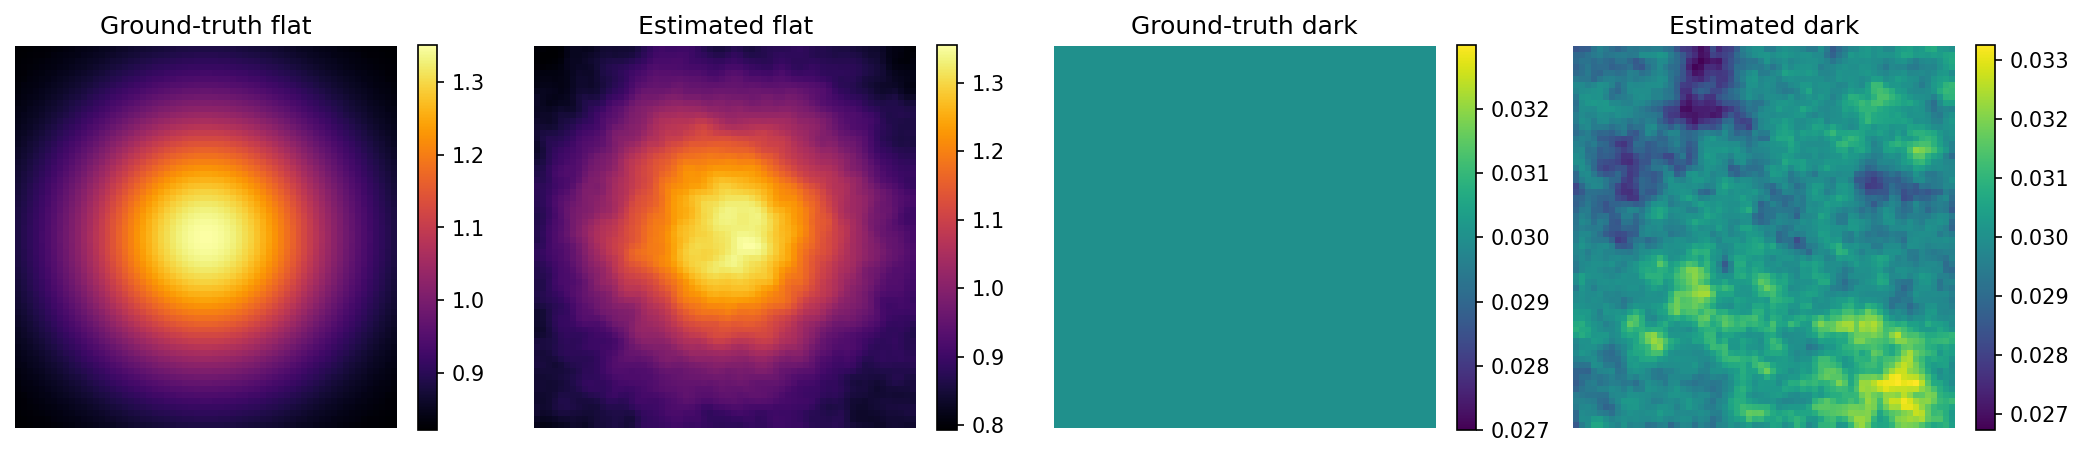

Flat-field Pearson r = 0.9920  (1.0 = perfect)


In [6]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3))

im = axes[0].imshow(gt_flat, cmap="inferno")
axes[0].set_title("Ground-truth flat")
plt.colorbar(im, ax=axes[0], fraction=0.046)

im = axes[1].imshow(flatfield, cmap="inferno")
axes[1].set_title("Estimated flat")
plt.colorbar(im, ax=axes[1], fraction=0.046)

im = axes[2].imshow(gt_dark, cmap="viridis")
axes[2].set_title("Ground-truth dark")
plt.colorbar(im, ax=axes[2], fraction=0.046)

im = axes[3].imshow(darkfield, cmap="viridis")
axes[3].set_title("Estimated dark")
plt.colorbar(im, ax=axes[3], fraction=0.046)

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Correlation between estimated and ground-truth flat-field
corr = float(np.corrcoef(gt_flat.ravel(), flatfield.ravel())[0, 1])
print(f"Flat-field Pearson r = {corr:.4f}  (1.0 = perfect)")

### Apply correction and compare

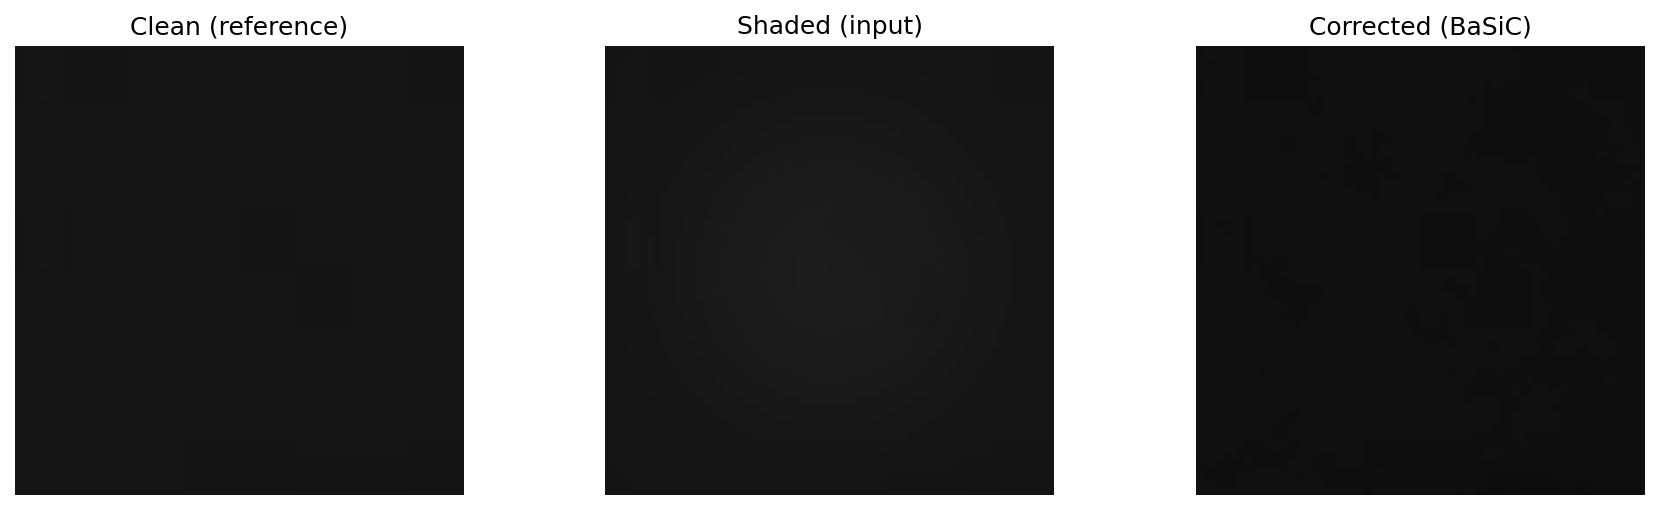

CV (clean)     : 0.4499
CV (shaded)    : 0.3772
CV (corrected) : 0.4505


In [7]:
# model.normalize() applies the correction to a single image
corrected = np.stack([model.normalize(shaded[i]) for i in range(len(shaded))])

# Before/after for a single patch
idx = 0
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
kwargs = {"cmap": "gray", "vmin": 0, "vmax": 1}
axes[0].imshow(clean[idx], **kwargs)
axes[0].set_title("Clean (reference)")
axes[1].imshow(shaded[idx], **kwargs)
axes[1].set_title("Shaded (input)")
axes[2].imshow(corrected[idx].clip(0, 1), **kwargs)
axes[2].set_title("Corrected (BaSiC)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


# Coefficient of Variation (lower = more uniform illumination)
def cv(stack: np.ndarray) -> float:
    """Mean coefficient of variation across a stack."""
    per_image = stack.reshape(len(stack), -1)
    return float((per_image.std(axis=1) / (per_image.mean(axis=1) + 1e-9)).mean())


print(f"CV (clean)     : {cv(clean):.4f}")
print(f"CV (shaded)    : {cv(shaded):.4f}")
print(f"CV (corrected) : {cv(corrected):.4f}")

## 4. Method chaining

`run()` returns `self`, so you can chain directly into `get_flatfield()`:

In [8]:
flatfield_chain = BaSiC(shaded).run().get_flatfield()
print(f"Chained flatfield shape: {flatfield_chain.shape}  mean={flatfield_chain.mean():.4f}")

Chained flatfield shape: (64, 64)  mean=1.0000


## Next steps

* **Dark-field & tuning** — `estimate_darkfield=True` + manual `l_s` / `l_d`
  override with `prepare()` inspection.
* **Mosaic pipelines** — `MosaicGrid`, `fit_mosaic()`, seam metrics,
  and the `basic fit` CLI sub-command.
* **Advanced** — GPU backend via `backend='torch'`, parallel z-level
  fitting with `n_workers`, and zarr I/O with `linum_basic.io.zarr`.

For the full comprehensive example including `sbh-simulator`-based ground
truth, see the [Comprehensive Usage](basic_usage.ipynb) notebook.